<H1>Assignment 4: Gaussian Discriminant Analysis</H1>

We will implemente Quadratic Discriminant Analysis (QDA) and Linear Discriminant Analysis (LDA) using scikit-learn. After training both models, we'll visualize their decision boundaries alongside the test data to compare their performance and decision-making visually. 

<H2>Objective:</H2> Implement both Linear Discriminant Analysis and Quadratic Discriminant Analysis using scikit-learn to classify the species of iris flowers. Evaluate the accuracy for the first two features. Plot the decision boundaries of both classifiers to visualize and compare their performance. Compare the accuarcy for the first two features and all features. 

<b>Task:</b> 
<ol>
  <li>Load the Iris dataset from scikit-learn.
</li>
  <li>For simplicity and visualization purposes, use only the first two features of the dataset (e.g., sepal length and sepal width).</li>
  <li>Split the dataset into training and testing sets (70% training, 30% testing).
</li>
  <li>Implement LDA and QDA using scikit-learn.
</li>
  <li>Plot the decision boundaries of both LDA and QDA, alongside with the test data, to visualize their differences (use contourf and scatter plots). Generate a meshgrid to cover the feature space and uses the trained models to predict the class for each point in the meshgrid, thus creating decision boundaries.
</li>
  <li>Evaluate the accuracy of the classifier and compare the results using two and all features.
</li>   
</ol>


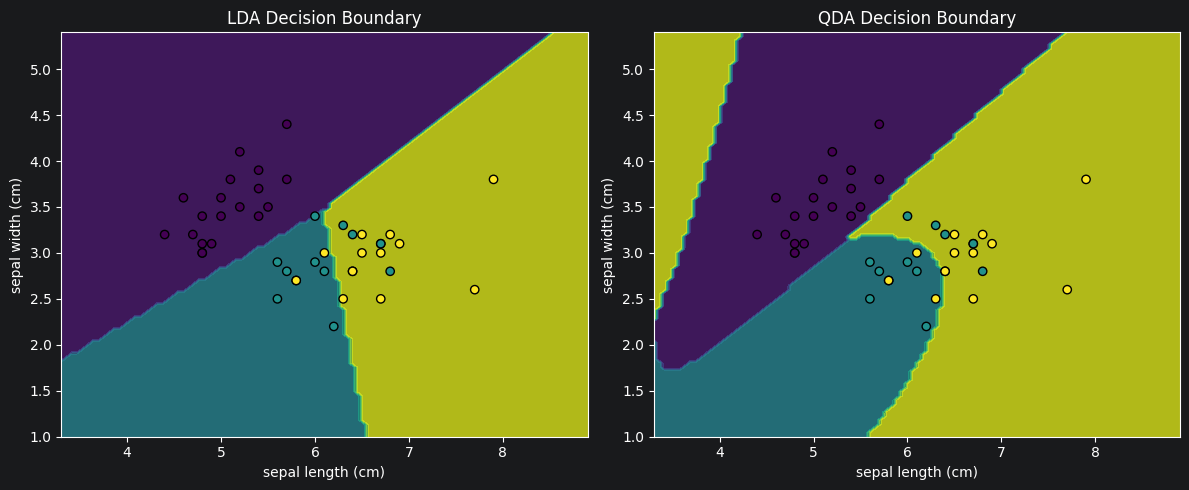

LDA Accuracy (first two features): 0.84
QDA Accuracy (first two features): 0.80
LDA Accuracy (all features): 1.00
QDA Accuracy (all features): 1.00


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# 1. & 2.
iris = datasets.load_iris()
X = iris.data[:, :2]  # Use only the first two features
y = iris.target

# 3.
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4.
def train_classifiers(x_train, y_train):
    lda_train = LinearDiscriminantAnalysis()
    qda_train = QuadraticDiscriminantAnalysis()
    lda_train.fit(x_train, y_train)
    qda_train.fit(x_train, y_train)
    return lda_train, qda_train

lda, qda = train_classifiers(X_train, Y_train)

# 5.

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
pred_lda = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
pred_qda = qda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, pred_lda, alpha=0.8)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolor='k', marker='o')
plt.title('LDA Decision Boundary')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, pred_qda, alpha=0.8)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolor='k', marker='o')
plt.title('QDA Decision Boundary')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.tight_layout()
plt.show()

# 6. two features
y_pred_lda = lda.predict(X_test)
y_pred_qda = qda.predict(X_test)
accuracy_lda = accuracy_score(Y_test, y_pred_lda)
accuracy_qda = accuracy_score(Y_test, y_pred_qda)
print(f'LDA Accuracy (first two features): {accuracy_lda:.2f}')
print(f'QDA Accuracy (first two features): {accuracy_qda:.2f}')

# all features
X_full = iris.data
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size=0.3, random_state=42)

lda_full, qda_full = train_classifiers(X_train_full, y_train_full)

y_pred_lda_full = lda_full.predict(X_test_full)
y_pred_qda_full = qda_full.predict(X_test_full)
accuracy_lda_full = accuracy_score(y_test_full, y_pred_lda_full)
accuracy_qda_full = accuracy_score(y_test_full, y_pred_qda_full)
print(f'LDA Accuracy (all features): {accuracy_lda_full:.2f}')
print(f'QDA Accuracy (all features): {accuracy_qda_full:.2f}')